In [23]:
from Becker_eta_f import compute_eta_f
from loadPressureData import loadPressureData
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from BulkWaveStats import detide, Spp_to_Seta, sig_wave_height
from scipy.signal import spectrogram
import pandas as pd
import xarray as xr
from Becker_eta_i import compute_eta_i


In [ ]:
dat4a = loadPressureData(Path("data/MoA48411.mat"))
dat4b = loadPressureData(Path("data/MoB48412"))

In [21]:
# INPUT VALUES
fs = 1
nperseg = 7200 # 2 hr windows
noverlap = nperseg * 0.75 # 75% overlap
LAT = 21.58055556

## ----- Sensor 1 (NEARSHORE)----- ##
bursts1 = loadPressureData(Path("data/MoA18411.mat"))
t1, h1, p1 = bursts1.time, bursts1.depth_m, bursts1.pressure_pa
# detide
tide1, p1_detide, p1_raw = detide(p1, t1, LAT = LAT)
# PSD of eta
freqs1, t1_spec, Spp1 = spectrogram(p1_detide, fs=fs, window = 'hann', nperseg = nperseg, noverlap = nperseg/2, detrend = 'linear', scaling = 'density',mode='psd', )
Seta1, t_eta1, h_eta1 = Spp_to_Seta(Spp1, freqs1, t1_spec, t1, h1)


bursts4 = loadPressureData(Path("data/MoA48411.mat"))
t4, h4, p4 = bursts4.time, bursts4.depth_m, bursts4.pressure_pa
# detide
tide4, p4_detide, p4_raw = detide(p4, t4, LAT = LAT)
# PSD of eta
freqs4, t4_spec, Spp4 = spectrogram(p4_detide, fs=fs, window = 'hann', nperseg = nperseg, noverlap = nperseg/2, detrend = 'linear', scaling = 'density',mode='psd', )
Seta4, t_eta4, h_eta4 = Spp_to_Seta(Spp4, freqs4, t4_spec, t4, h4)

bursts4b = loadPressureData(Path("data/MoB48411.mat"))
t4b, h4b, p4b = bursts4b.time, bursts4b.depth_m, bursts4b.pressure_pa
# detide
tide4b, p4b_detide, p4b_raw = detide(p4b, t4b, LAT = LAT)
# PSD of eta
freqs4b, t4b_spec, Spp4b = spectrogram(p4b_detide, fs=fs, window = 'hann', nperseg = nperseg, noverlap = nperseg/2, detrend = 'linear', scaling = 'density',mode='psd', )
Seta4b, t_eta4b, h_eta4b = Spp_to_Seta(Spp4b, freqs4b, t4b_spec, t4b, h4b)

prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.


In [65]:
## My idea to compute eta_i
# eta_i = h_i - h_f + eta_f

# compute eta_f at reef face
ds_4 = compute_eta_f(Seta4, freqs4, t_eta4, -h_eta4)
ds_4b = compute_eta_f(Seta4b, freqs4b, t_eta4b, -h_eta4b)


# convert to pd dataframe bc i know how to use those 
S1 = pd.DataFrame().assign(
    time = bursts1.time,
    pressure = bursts1.pressure_pa, 
    h = bursts1.depth_m
).set_index('time')
eta_f = ds_f.to_dataframe()

# align time indices
idx = S1.index.intersection(eta_f.index)
S1 = S1.loc[idx]
eta_f = eta_f.loc[idx]

# equation variables
hi = S1['h']
hf = eta_f['h_f']
etaf = eta_f['eta_f']

etai = hi - hf + etaf



In [67]:
ds_4

<xarray.Dataset> Size: 16kB
Dimensions:  (time: 336)
Coordinates:
  * time     (time) datetime64[ns] 3kB 2007-12-14T01:00:00 ... 2007-12-28
Data variables:
    eta_f    (time) float64 3kB -0.001585 -0.001578 ... -0.0007936 -0.001034
    H_rms    (time) float64 3kB 0.5037 0.5078 0.5298 ... 0.299 0.3413 0.3853
    k_f      (time) float64 3kB 0.1403 0.1417 0.1429 ... 0.1317 0.1257 0.1276
    h_f      (time) float64 3kB 6.258 6.297 6.028 5.922 ... 6.179 6.256 6.135
    f_rep    (time) float64 3kB 0.1568 0.1584 0.1574 ... 0.1483 0.1432 0.1441
Attributes:
    equation:     eta_f = -(H_f^2 k_f) / (8 sinh(2 k_f h_f))
    band:         (0.05, 0.33)
    freq_units:   Hz
    depth_units:  m (positive downward)
    Seta_units:   m^2/Hz
    notes:        Hrms from band-limited m0; f_rep is energy-weighted mean fr...

<Axes: xlabel='time'>

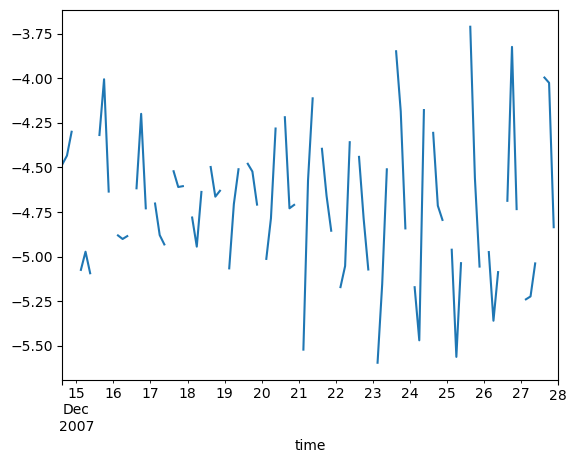

In [63]:
import matplotlib.pyplot as plt

etai.plot()

In [35]:
import numpy as np
import pandas as pd
import xarray as xr

def compute_eta_i_simple(ds_eta_f: xr.Dataset, h_i, h_i_time, tolerance: str | None = "10min") -> xr.Dataset:
    """
    Minimal helper:
      eta_i(t) = eta_f(t) + (h_i(t) - h_f(t))

    Assumptions:
      - ds_eta_f has variables 'eta_f' and 'h_f' and coord 'time'
      - h_i is 1D array-like, h_i_time is same-length datetime-like
      - depths are meters, positive downward (we enforce abs)
    """
    # build h_i as DataArray on its own time axis
    ti = pd.to_datetime(h_i_time).values.astype("datetime64[ns]")
    h_i_da = xr.DataArray(np.asarray(h_i, float), coords={"time": ti}, dims=("time",), name="h_i").sortby("time")

    # align by nearest, but use REINDEX so out-of-tolerance -> NaN (no KeyError)
    if tolerance is None:
        h_i_on_face = h_i_da.reindex(time=ds_eta_f.time, method="nearest")
    else:
        h_i_on_face = h_i_da.reindex(time=ds_eta_f.time, method="nearest", tolerance=pd.to_timedelta(tolerance))

    # force depths positive
    h_f = np.abs(ds_eta_f["h_f"])
    h_i_on_face = np.abs(h_i_on_face)

    # keep only times where we actually have a match for h_i
    valid = h_i_on_face.notnull()

    # compute eta_i on valid times
    eta_i = (ds_eta_f["eta_f"] + (h_i_on_face - h_f)).rename("eta_i")

    # return a tidy dataset containing only valid timestamps
    out = ds_eta_f.sel(time=ds_eta_f.time.where(valid, drop=True)).copy()
    out["h_i"] = h_i_on_face.sel(time=out.time)
    out["eta_i"] = eta_i.sel(time=out.time)
    return out


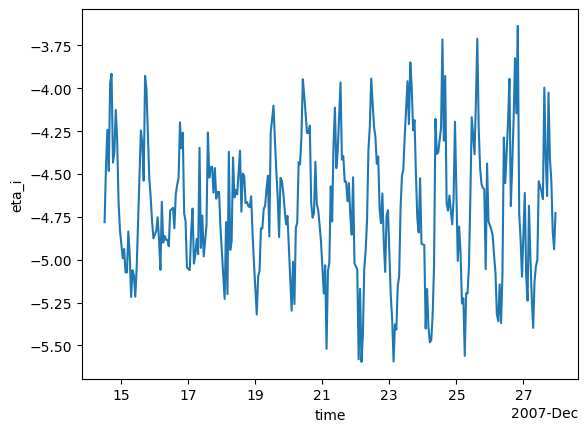

In [36]:
ds = compute_eta_i_simple(ds_f, h1, t1)
ds.eta_i.plot()